> ### ⚠️ AUDIT BANNER — Scope, Fidelity & Corrections (added by reproducibility audit)
>
> **Dataset scope:** This notebook trains ACS-SegNet on **SegPath** (endothelium / epithelium / smooth-muscle), *not* on GCPS or PUMA (the datasets in the paper). The architecture, loss, optimizer, LR schedule and metric are audited against the official repo and are faithful; **the paper's Table 1/2 numbers do NOT apply to SegPath** and are not a valid target here.
> **Deliberate deviations from the official `train.py` (all documented):**
> - `epochs` set to **150** (repo default) — lower it for faster runs on limited GPUs.
> - `batch_size` **4** (repo uses 8) — chosen for T4 memory; affects BN stats & micro-metric granularity slightly.
> - Augmentation exposes a `USE_INTENSITY_AUG` flag: repo `train.py` uses **only** flip+rotate+resize; the *paper text* also mentions intensity augs. Default True = paper-style; set False to match the repo exactly.
> - Added a **true paper µ-metric** evaluator (Eq. 1–3: whole val set as one image, micro-per-class then averaged) — the repo's `iou_score`+`AverageMeter` is a per-batch average and is kept for repo-parity, but the paper-protocol number is now reported alongside it.
>
> Fixes already present in this notebook and verified correct: mask binarisation via `>0` (handles {0,1} & {0,255}); `smp==0.3.4` pin for `Conv2dReLU(use_batchnorm=...)`; poly-LR `max_iters = epochs*len(loader)` (repairs the repo's undefined `max_iterations` in `train.py`).

---
# ACS-SegNet on SegPath Dataset (Endothelium / Epithelium / Smooth Muscle)

**Paper:** ACS-SegNet: An Attention-based CNN-SegFormer Segmentation Network for Tissue Segmentation in Histopathology  
**Dataset:** SegPath — 3 cell types, 100 images + 100 masks each  
**Task:** Binary segmentation (foreground tissue vs background)

---
## SegPath Naming Convention

This notebook is built around the **exact** SegPath filenames:

| Cell Type | Image filename | Mask filename |
|-----------|---------------|---------------|
| Endothelium | `ERG_Endothelium_024_067584_052224_HE.png` | `ERG_Endothelium_024_067584_052224_mask.png` |
| Epithelium | `panCK_Epithelium_023_011264_009216_HE.png` | `panCK_Epithelium_023_011264_009216_mask.png` |
| Smooth Muscle | `aSMA_SmoothMuscle_016_008192_061440_HE.png` | `aSMA_SmoothMuscle_016_008192_061440_mask.png` |

The shared **base ID** (everything before `_HE` or `_mask`) is used to pair images with their masks automatically.

---
## Required Google Drive Structure

Zip **exactly** this folder and upload to Google Drive:
```
SegPath_sorted/
├── endothelium/
│   ├── images/    ← e.g. ERG_Endothelium_024_067584_052224_HE.png
│   └── masks/     ← e.g. ERG_Endothelium_024_067584_052224_mask.png
├── epithelium/
│   ├── images/    ← e.g. panCK_Epithelium_023_011264_009216_HE.png
│   └── masks/     ← e.g. panCK_Epithelium_023_011264_009216_mask.png
└── smooth_muscle/
    ├── images/    ← e.g. aSMA_SmoothMuscle_016_008192_061440_HE.png
    └── masks/     ← e.g. aSMA_SmoothMuscle_016_008192_061440_mask.png
```
On Windows: right-click `SegPath_sorted` → Send to → Compressed (zipped) folder, then drag into Google Drive.

---

## Cell 1 — Install Dependencies

In [1]:
# ── Install all required packages ──────────────────────────────────────────────
# FIX: pin segmentation-models-pytorch to 0.3.4 -- the last release before the
# `use_batchnorm` -> `use_norm` rename in Conv2dReLU (smp 0.4.0+). ACS-SegNet's
# unet_decoder/decoder.py calls Conv2dReLU(use_batchnorm=...), which breaks on
# unpinned/newer smp with: TypeError: Conv2dReLU.__init__() got an unexpected
# keyword argument 'use_batchnorm'
# FIX(F2): pin albumentations==1.3.1 -> keeps `Flip`, `GaussNoise(var_limit=...)`,
#          `RandomRotate90` with the exact API the repo/paper augmentation uses
#          (albumentations>=2.0 removed `Flip` and changed `GaussNoise`).
!pip install -q transformers segmentation-models-pytorch==0.3.4 albumentations==1.3.1
!pip install -q matplotlib scikit-learn

import torch
print(f'PyTorch        : {torch.__version__}')
print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU detected. Go to Runtime > Change runtime type > T4 GPU')

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 47.6 MB/s eta 0:00:00
PyTorch        : 2.11.0+cu128
CUDA available : True
GPU            : Tesla T4


## Cell 2 — Mount Google Drive & Unzip Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile

# ── EDIT: path to the zip you uploaded in Google Drive ─────────────────────────
DRIVE_ZIP_PATH = '/content/drive/MyDrive/SegPath_sorted.zip'
EXTRACT_DIR    = '/content/SegPath_sorted'
# ───────────────────────────────────────────────────────────────────────────────

if not os.path.exists(EXTRACT_DIR):
    print('Extracting dataset ...')
    with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as z:
        z.extractall('/content/')
    print('Done.')
else:
    print('Dataset already extracted.')

# ── Verify counts ──────────────────────────────────────────────────────────────
print()
print(f'{"Cell Type":<20}  {"Images":>8}  {"Masks":>8}')
print('-' * 42)
for ct in ['endothelium', 'epithelium', 'smooth_muscle']:
    img_dir  = os.path.join(EXTRACT_DIR, ct, 'images')
    mask_dir = os.path.join(EXTRACT_DIR, ct, 'masks')
    n_imgs   = len([f for f in os.listdir(img_dir)  if not f.startswith('.')]) if os.path.exists(img_dir)  else 0
    n_masks  = len([f for f in os.listdir(mask_dir) if not f.startswith('.')]) if os.path.exists(mask_dir) else 0
    status   = '✓' if n_imgs == n_masks else '✗ MISMATCH'
    print(f'{ct:<20}  {n_imgs:>8}  {n_masks:>8}  {status}')

Mounted at /content/drive
Extracting dataset ...
Done.

Cell Type               Images     Masks
------------------------------------------
endothelium                100       100  ✓
epithelium                 100       100  ✓
smooth_muscle              100       100  ✓


## Cell 3 — Clone ACS-SegNet Repository

In [3]:
import os
REPO_DIR = '/content/ACS-SegNet'

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/NimaTorbati/ACS-SegNet.git {REPO_DIR}
else:
    print('Repo already cloned.')

os.chdir(REPO_DIR)
print('Working directory:', os.getcwd())
print('Top-level files  :', [f for f in os.listdir('.') if not f.startswith('.')])

Cloning into '/content/ACS-SegNet'...
remote: Enumerating objects: 319, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 319 (delta 35), reused 10 (delta 2), pack-reused 256 (from 1)
Receiving objects: 100% (319/319), 319.56 KiB | 6.27 MiB/s, done.
Resolving deltas: 100% (154/154), done.
Working directory: /content/ACS-SegNet
Top-level files  : ['train.py', 'Puma_Train.py', 'ModelWeights', 'networks', 'checkpoint', 'utils', 'model.py', 'unet_decoder', 'model', 'src', 'data', 'DGAUNet_train.py', 'README.md']


## Cell 4 — Configuration

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CONFIGURATION  — only edit this cell
# ═══════════════════════════════════════════════════════════════════════════════

CFG = {
    # ── Dataset ───────────────────────────────────────────────────────────────
    'data_root'  : '/content/SegPath_sorted',
    'data_dir'   : '/content/ACS_data',       # merged flat dataset lives here

    # SegPath naming: image = <base_id>_HE.png  |  mask = <base_id>_mask.png
    # Map each subfolder name → (image suffix, mask suffix)
    'cell_types' : {
        'endothelium'  : ('_HE', '_mask'),
        'epithelium'   : ('_HE', '_mask'),
        'smooth_muscle': ('_HE', '_mask'),
    },

    # ── Model ─────────────────────────────────────────────────────────────────
    'img_size'      : 256,    # paper uses 256 for the GCPS binary task
    'num_classes'   : 1,      # binary segmentation
    'segformer_var' : 'nvidia/segformer-b2-finetuned-ade-512-512',
    'resnet_enc'    : 'resnet34',
    'decoder_ch'    : (256, 128, 64, 32, 16),
    'simple_fusion' : 1,      # 0 = CS-SegNet (concat only)  |  1 = ACS-SegNet (CBAM)
    'use_intensity_aug': True, # FIX(F5): True=paper-style (hue/sat/bri/con); False=repo train.py exactly (flip+rotate only)

    # ── Training ──────────────────────────────────────────────────────────────
    'epochs'        : 150,    # FIX(F3): repo/paper default is 150 (was 100). Lower for speed.
    'batch_size'    : 4,      # safe for T4 GPU at 256 px; reduce to 2 if OOM
    'lr'            : 0.01,
    'momentum'      : 0.9,
    'weight_decay'  : 1e-4,
    'n_folds'       : 3,      # 3-fold CV matching the paper
    'seed'          : 42,

    # ── Output paths ──────────────────────────────────────────────────────────
    'checkpoint_dir': '/content/checkpoints',
    'result_dir'    : '/content/results',
    'drive_save'    : '/content/drive/MyDrive/ACS_SegNet_SegPath',  # mirrored to Drive
}

import os
for d in [CFG['data_dir'], CFG['checkpoint_dir'], CFG['result_dir'], CFG['drive_save']]:
    os.makedirs(d, exist_ok=True)

print('Configuration ready. Output folders created.')
print(f'  Merged data    : {CFG["data_dir"]}')
print(f'  Checkpoints    : {CFG["checkpoint_dir"]}')
print(f'  Drive backup   : {CFG["drive_save"]}')

Configuration ready. Output folders created.
  Merged data    : /content/ACS_data
  Checkpoints    : /content/checkpoints
  Drive backup   : /content/drive/MyDrive/ACS_SegNet_SegPath


## Cell 5 — Build Merged Dataset + 3-Fold Split Files

This cell:
1. Scans each `images/` folder for `*_HE.png` files
2. Strips the `_HE` suffix to get the **base ID** (e.g. `ERG_Endothelium_024_067584_052224`)
3. Looks for the paired `<base_id>_mask.png` in the `masks/` folder
4. Copies both into a single flat `ACS_data/images/` and `ACS_data/masks/` directory,  
   prefixed with the cell-type name to avoid filename collisions
5. Writes three `SegPath{fold}_train.txt` / `SegPath{fold}_val.txt` split files

In [5]:
import os, shutil, random
import numpy as np

random.seed(CFG['seed'])
np.random.seed(CFG['seed'])

merged_imgs  = os.path.join(CFG['data_dir'], 'images')
merged_masks = os.path.join(CFG['data_dir'], 'masks')
os.makedirs(merged_imgs,  exist_ok=True)
os.makedirs(merged_masks, exist_ok=True)

all_stems   = []   # flat list of unified stems for the dataloader
skipped     = []   # pairs where the mask was not found

for ct, (img_sfx, msk_sfx) in CFG['cell_types'].items():
    img_src  = os.path.join(CFG['data_root'], ct, 'images')
    msk_src  = os.path.join(CFG['data_root'], ct, 'masks')

    # Collect every image file that ends with the expected image suffix
    img_files = sorted([
        f for f in os.listdir(img_src)
        if f.lower().endswith('.png') and (img_sfx.lower() in f.lower())
    ])

    print(f'\n{ct}: found {len(img_files)} image files')

    paired = 0
    for fname in img_files:
        # ── Derive base ID by stripping the image suffix + extension ──────────
        # e.g. 'ERG_Endothelium_024_067584_052224_HE.png'  →  'ERG_Endothelium_024_067584_052224'
        ext     = os.path.splitext(fname)[1]           # '.png'
        no_ext  = os.path.splitext(fname)[0]           # '..._HE'
        if no_ext.endswith(img_sfx):
            base_id = no_ext[: -len(img_sfx)]          # strip '_HE'
        else:
            base_id = no_ext                           # fallback: use full stem

        mask_fname = base_id + msk_sfx + ext           # e.g. '..._mask.png'
        src_mask   = os.path.join(msk_src, mask_fname)

        if not os.path.exists(src_mask):
            skipped.append(f'{ct}/{fname}  →  missing {mask_fname}')
            continue

        # ── Build a collision-safe unified stem for the merged dataset ─────────
        # e.g.  'endothelium__ERG_Endothelium_024_067584_052224'
        unified_stem = f'{ct}__{base_id}'

        # ── Copy image ────────────────────────────────────────────────────────
        dst_img = os.path.join(merged_imgs,  unified_stem + '.png')
        if not os.path.exists(dst_img):
            shutil.copy(os.path.join(img_src, fname), dst_img)

        # ── Copy mask ─────────────────────────────────────────────────────────
        dst_msk = os.path.join(merged_masks, unified_stem + '.png')
        if not os.path.exists(dst_msk):
            shutil.copy(src_mask, dst_msk)

        all_stems.append(unified_stem)
        paired += 1

    print(f'  Successfully paired: {paired}')

# ── Report any missing masks ───────────────────────────────────────────────────
if skipped:
    print(f'\nWARNING — {len(skipped)} image(s) had no matching mask:')
    for s in skipped: print(' ', s)

print(f'\nTotal paired samples: {len(all_stems)}')

# ── 3-Fold cross-validation split ─────────────────────────────────────────────
random.shuffle(all_stems)
folds = np.array_split(all_stems, CFG['n_folds'])

print(f'\n3-Fold split summary:')
for i in range(CFG['n_folds']):
    val_stems   = list(folds[i])
    train_stems = [s for j, fold in enumerate(folds) for s in fold if j != i]

    with open(os.path.join(CFG['data_dir'], f'SegPath{i}_train.txt'), 'w') as f:
        f.write('\n'.join(train_stems))
    with open(os.path.join(CFG['data_dir'], f'SegPath{i}_val.txt'), 'w') as f:
        f.write('\n'.join(val_stems))

    # Per-class counts inside this fold's val set
    counts = {ct: sum(1 for s in val_stems if s.startswith(ct)) for ct in CFG['cell_types']}
    print(f'  Fold {i}:  train={len(train_stems):3d}  val={len(val_stems):3d}  '
          f'({"  ".join(f"{ct[:4]}={n}" for ct,n in counts.items())})')

print('\nSplit files written to:', CFG['data_dir'])


endothelium: found 100 image files
  Successfully paired: 100

epithelium: found 100 image files
  Successfully paired: 100

smooth_muscle: found 100 image files
  Successfully paired: 100

Total paired samples: 300

3-Fold split summary:
  Fold 0:  train=200  val=100  (endo=26  epit=30  smoo=44)
  Fold 1:  train=200  val=100  (endo=35  epit=34  smoo=31)
  Fold 2:  train=200  val=100  (endo=39  epit=36  smoo=25)

Split files written to: /content/ACS_data


## Cell 6 — Verify a Sample Pair from Each Cell Type

endothelium           img=(984, 984, 3)  mask unique=[0]  foreground=0.0%
epithelium            img=(984, 984, 3)  mask unique=[0 1]  foreground=7.4%
smooth_muscle         img=(984, 984, 3)  mask unique=[0 1]  foreground=15.8%


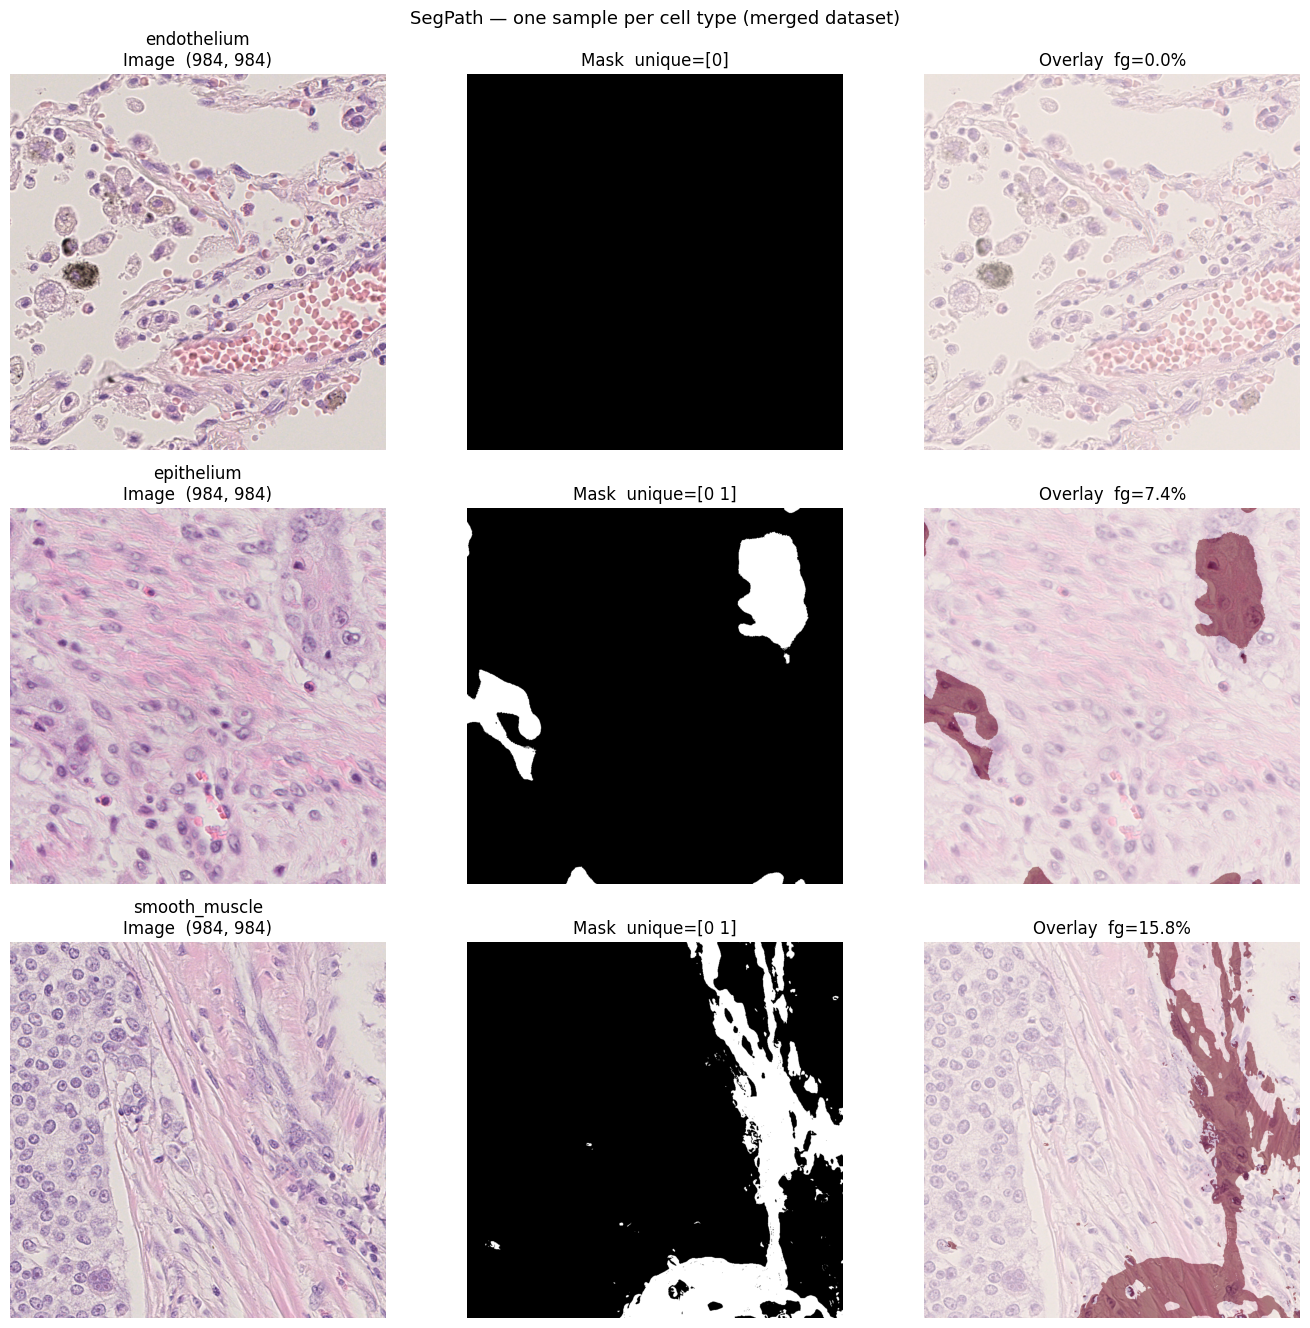

In [6]:
import cv2, matplotlib.pyplot as plt, numpy as np

# Pick one sample per cell type for visual verification
samples = {ct: None for ct in CFG['cell_types']}
for stem in all_stems:
    ct = stem.split('__')[0]
    if samples[ct] is None:
        samples[ct] = stem
    if all(v is not None for v in samples.values()):
        break

fig, axes = plt.subplots(len(samples), 3, figsize=(14, 4.5 * len(samples)))

for row, (ct, stem) in enumerate(samples.items()):
    img  = cv2.cvtColor(
        cv2.imread(os.path.join(CFG['data_dir'], 'images', stem + '.png')),
        cv2.COLOR_BGR2RGB
    )
    mask = cv2.imread(os.path.join(CFG['data_dir'], 'masks', stem + '.png'), cv2.IMREAD_GRAYSCALE)
    # NOTE: SegPath masks may be label-encoded {0,1} rather than {0,255} binary masks.
    # mask_vis is rescaled purely for *display* (imshow); mask itself stays raw for the unique() check.
    mask_vis = (mask > 0).astype('uint8') * 255

    # Print diagnostic info
    uniq = np.unique(mask)
    coverage = round(100 * (mask > 0).sum() / mask.size, 1)   # FIX: was `mask > 127`, which silently
                                                                #      zeroed out coverage for {0,1}-encoded masks
    print(f'{ct:<20}  img={img.shape}  mask unique={uniq}  foreground={coverage}%')

    axes[row][0].imshow(img)
    axes[row][0].set_title(f'{ct}\nImage  {img.shape[:2]}')
    axes[row][0].axis('off')

    axes[row][1].imshow(mask_vis, cmap='gray')   # FIX: display the rescaled mask, not the raw {0,1} values
    axes[row][1].set_title(f'Mask  unique={uniq}')
    axes[row][1].axis('off')

    overlay = img.copy()
    axes[row][2].imshow(overlay)
    axes[row][2].imshow(mask_vis, alpha=0.45, cmap='Reds')   # FIX: same rescaling for the overlay
    axes[row][2].set_title(f'Overlay  fg={coverage}%')
    axes[row][2].axis('off')

plt.suptitle('SegPath — one sample per cell type (merged dataset)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(CFG['drive_save'], 'sample_verification.png'), dpi=120, bbox_inches='tight')
plt.show()

## Cell 6b — Scan All Masks for Value-Encoding Consistency (0/1 vs 0/255)

In [7]:
import os, numpy as np, cv2
from collections import defaultdict

print("Scanning all masks for value-encoding consistency...\n")
stats = defaultdict(lambda: {'unique_sets': set(), 'n_empty': 0, 'n_files': 0, 'max_val': 0})

for stem in all_stems:
    ct = stem.split('__')[0]
    mask_path = os.path.join(CFG['data_dir'], 'masks', stem + '.png')
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        print(f'  WARNING: could not read {mask_path}')
        continue
    uniq = tuple(np.unique(mask).tolist())
    stats[ct]['unique_sets'].add(uniq)
    stats[ct]['n_files'] += 1
    stats[ct]['max_val'] = max(stats[ct]['max_val'], int(mask.max()))
    if mask.max() == 0:
        stats[ct]['n_empty'] += 1

print(f"{'cell_type':<16} {'n_files':>8} {'n_empty':>8} {'max_val':>8}  distinct_unique_value_sets")
for ct, s in stats.items():
    shown = sorted(s['unique_sets'], key=lambda t: (len(t), t))[:5]
    suffix = ' ...' if len(s['unique_sets']) > 5 else ''
    print(f"{ct:<16} {s['n_files']:>8} {s['n_empty']:>8} {s['max_val']:>8}  {shown}{suffix}")

print("\nInterpretation:")
print("  max_val == 1   -> masks are label-encoded {0,1}, NOT {0,255}.")
print("                    The original `/255.0` then `>0.5` binarisation step zeroes EVERY mask -- training bug.")
print("  max_val == 255 -> masks are standard 0/255 binary masks (no issue).")
print("  n_empty > 0    -> some masks have zero foreground pixels. Could be a legitimate negative tile,")
print("                    or a data/copy issue -- worth spot-checking a few of those stems manually.")


Scanning all masks for value-encoding consistency...

cell_type         n_files  n_empty  max_val  distinct_unique_value_sets
epithelium            100        0        1  [(0, 1)]
smooth_muscle         100        0        1  [(0, 1)]
endothelium           100       67        1  [(0,), (0, 1)]

Interpretation:
  max_val == 1   -> masks are label-encoded {0,1}, NOT {0,255}.
                    The original `/255.0` then `>0.5` binarisation step zeroes EVERY mask -- training bug.
  max_val == 255 -> masks are standard 0/255 binary masks (no issue).
  n_empty > 0    -> some masks have zero foreground pixels. Could be a legitimate negative tile,
                    or a data/copy issue -- worth spot-checking a few of those stems manually.


## Cell 7 — Model, Dataset & Loss Definitions

In [8]:
import sys, os, random
sys.path.insert(0, '/content/ACS-SegNet')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import cv2
from albumentations import (
    Compose, RandomRotate90, HorizontalFlip, Resize,
    HueSaturationValue, RandomBrightnessContrast, GaussNoise
)

# ACS-SegNet repo modules
from model import DualEncoderUNet
from src.utils.metrics import iou_score
from src.utils.util import AverageMeter

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


# ── Reproducibility ───────────────────────────
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED']       = str(seed)

seed_everything(CFG['seed'])


# ── Dataset ─────────────────────────────
class SegPathDataset(Dataset):
    """
    Reads the merged flat dataset:
      <data_dir>/images/<unified_stem>.png
      <data_dir>/masks/<unified_stem>.png
    where unified_stem = '<cell_type>__<base_id>'
    e.g.  endothelium__ERG_Endothelium_024_067584_052224
    """
    def __init__(self, data_dir, split_file, transform=None):
        self.data_dir  = data_dir
        self.transform = transform
        with open(split_file, 'r') as f:
            self.stems = [l.strip() for l in f if l.strip()]
        print(f'  [{os.path.basename(split_file)}]  {len(self.stems)} samples')

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, idx):
        stem = self.stems[idx]
        img_path  = os.path.join(self.data_dir, 'images', stem + '.png')
        mask_path = os.path.join(self.data_dir, 'masks',  stem + '.png')

        # Load image (RGB) and mask (grayscale)
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)[..., None]  # (H,W,1)

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask']

        # Normalise image to [0,1] and convert to (C,H,W)
        image = (image.astype('float32') / 255.0).transpose(2, 0, 1)   # (3,H,W)

        # FIX: SegPath masks may be label-encoded {0,1} OR standard {0,255} binary masks.
        # The original `/255.0` + `>0.5` logic silently zeroed out every {0,1}-encoded mask
        # (1/255 ≈ 0.0039, never > 0.5), so the model trained against empty targets.
        # `> 0` works correctly for both encodings.
        mask = (mask > 0).astype('float32').transpose(2, 0, 1)         # (1,H,W), binarised

        return {
            'image': torch.tensor(image),
            'label': torch.tensor(mask),
            'stem' : stem,
        }


# ── Loss (BCEDice ─ identical to the original ACS-SegNet codebase) ──────────
class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, pred, target):
        bce    = F.binary_cross_entropy_with_logits(pred, target)
        smooth = 1e-5
        p      = torch.sigmoid(pred)
        n      = target.size(0)
        p_f    = p.view(n, -1)
        t_f    = target.view(n, -1)
        inter  = (p_f * t_f).sum(1)
        dice   = 1 - ((2 * inter + smooth) / (p_f.sum(1) + t_f.sum(1) + smooth)).mean()
        return 0.5 * bce + dice


# ── Build ACS-SegNet (DualEncoderUNet with CBAM) ───────────────
def build_model():
    model = DualEncoderUNet(
        unet_encoder_name    = CFG['resnet_enc'],          # resnet34
        unet_encoder_weights = 'imagenet',
        segformer_variant    = CFG['segformer_var'],        # segformer-b2
        classes              = CFG['num_classes'],          # 1
        decoder_channels     = CFG['decoder_ch'],           # (256,128,64,32,16)
        simple_fusion        = CFG['simple_fusion'],        # 1 = CBAM
        regression           = False,
        in_channels          = 3,
        model_depth          = 5,
        IgnoreBottleNeck     = False,
        input_size           = CFG['img_size'],
    ).to(DEVICE)
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  ACS-SegNet parameters: {n/1e6:.1f} M')
    return model


print('All definitions loaded.')

Device: cuda
All definitions loaded.


## Cell 8 — DataLoaders + Training / Validation Functions

In [9]:
import time
from collections import defaultdict


def _seed_worker(worker_id):
    # FIX(F6): make num_workers>0 reproducible (repo used num_workers=0)
    import random as _r, numpy as _np, torch as _t
    ws = (_t.initial_seed()) % 2**32
    _np.random.seed(ws); _r.seed(ws)

_g = torch.Generator(); _g.manual_seed(CFG['seed'])


def get_dataloaders(fold_idx):
    S = CFG['img_size']

    # FIX(F5): repo train.py uses Flip()+RandomRotate90()+Resize ONLY.
    # Paper text additionally mentions intensity augs -> toggle with CFG['use_intensity_aug'].
    from albumentations import Flip
    base = [RandomRotate90(p=0.5), Flip(p=0.5)]          # Flip = H or V, matches repo
    if CFG.get('use_intensity_aug', True):
        base += [
            HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.3),
            RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
        ]
    base += [Resize(S, S)]
    train_tf = Compose(base)
    val_tf   = Compose([Resize(S, S)])

    train_ds = SegPathDataset(
        CFG['data_dir'],
        os.path.join(CFG['data_dir'], f'SegPath{fold_idx}_train.txt'),
        transform=train_tf,
    )
    val_ds = SegPathDataset(
        CFG['data_dir'],
        os.path.join(CFG['data_dir'], f'SegPath{fold_idx}_val.txt'),
        transform=val_tf,
    )

    train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
                              shuffle=True,  num_workers=2, pin_memory=True,
                              worker_init_fn=_seed_worker, generator=_g)
    val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'],
                              shuffle=False, num_workers=2,
                              worker_init_fn=_seed_worker, generator=_g)
    return train_loader, val_loader


# ── One training epoch (poly-LR decay matching the paper) ───────────────────────
def train_one_epoch(model, loader, optimizer, criterion,
                    iter_num, max_iters, base_lr):
    model.train()
    meters = {k: AverageMeter() for k in ['loss', 'iou', 'dice']}

    for batch in loader:
        imgs   = batch['image'].to(DEVICE)
        labels = batch['label'].to(DEVICE)

        preds = model(imgs)
        loss  = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Poly LR
        lr_now = base_lr * (1.0 - iter_num / max_iters) ** 0.9
        for pg in optimizer.param_groups:
            pg['lr'] = lr_now
        iter_num += 1

        iou, dice, *_ = iou_score(preds, labels)
        bs = imgs.size(0)
        meters['loss'].update(loss.item(), bs)
        meters['iou'].update(iou,  bs)
        meters['dice'].update(dice, bs)

    return meters, iter_num


# ── Validation pass ─────────────────────────────────────────────────────────────
@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    keys   = ['loss', 'iou', 'dice', 'SE', 'PC', 'F1', 'SP', 'ACC']
    meters = {k: AverageMeter() for k in keys}

    for batch in loader:
        imgs   = batch['image'].to(DEVICE)
        labels = batch['label'].to(DEVICE)
        preds  = model(imgs)
        loss   = criterion(preds, labels)
        iou, dice, SE, PC, F1, SP, ACC = iou_score(preds, labels)
        bs = imgs.size(0)
        for k, v in zip(keys, [loss.item(), iou, dice, SE, PC, F1, SP, ACC]):
            meters[k].update(v, bs)

    return meters


print('Dataloader and loop functions defined.')

Dataloader and loop functions defined.


## Cell 9 — Full Training Loop (3-Fold Cross Validation)

In [10]:
import shutil

fold_results   = {}   # fold_idx → best val IoU
fold_histories = {}   # fold_idx → metric history dict
last_model      = None
last_val_loader = None


def run_fold(fold_idx):
    print(f'\n{"="*65}')
    print(f'  FOLD {fold_idx + 1} / {CFG["n_folds"]}')
    print(f'{"="*65}')

    train_loader, val_loader = get_dataloaders(fold_idx)
    model     = build_model()
    criterion = BCEDiceLoss().to(DEVICE)
    optimizer = optim.SGD(
        model.parameters(),
        lr=CFG['lr'], momentum=CFG['momentum'], weight_decay=CFG['weight_decay']
    )

    max_iters = CFG['epochs'] * len(train_loader)
    iter_num  = 0
    best_iou  = 0.0
    history   = defaultdict(list)
    ckpt_path = os.path.join(CFG['checkpoint_dir'], f'ACSSegNet_fold{fold_idx}_best.pth')

    for epoch in range(1, CFG['epochs'] + 1):
        t0 = time.time()

        train_m, iter_num = train_one_epoch(
            model, train_loader, optimizer, criterion,
            iter_num, max_iters, CFG['lr']
        )
        val_m = validate(model, val_loader, criterion)
        elapsed = time.time() - t0

        # Record history
        for k in train_m:
            history[f'train_{k}'].append(train_m[k].avg)
        for k in val_m:
            history[f'val_{k}'].append(val_m[k].avg)

        # Log every 10 epochs (and epoch 1)
        if epoch == 1 or epoch % 10 == 0:
            print(
                f'  Ep {epoch:3d}/{CFG["epochs"]}  '
                f'loss={train_m["loss"].avg:.4f}  iou={train_m["iou"].avg:.4f} | '
                f'val_loss={val_m["loss"].avg:.4f}  val_iou={val_m["iou"].avg:.4f}  '
                f'val_dice={val_m["dice"].avg:.4f}  [{elapsed:.1f}s]'
            )

        # Save best checkpoint
        if val_m['iou'].avg > best_iou:
            best_iou = val_m['iou'].avg
            torch.save(model.state_dict(), ckpt_path)
            print(f'  ★ Best val_iou={best_iou:.4f}  (epoch {epoch}) — saved')

    # Mirror best checkpoint to Google Drive
    shutil.copy(ckpt_path, os.path.join(CFG['drive_save'], os.path.basename(ckpt_path)))
    print(f'\nFold {fold_idx} done.  Best val IoU = {best_iou:.4f}')

    return best_iou, dict(history), model, val_loader


# ── Run all folds ────────────────────────────────────────────────────────────────
for fi in range(CFG['n_folds']):
    best_iou, history, model, val_loader = run_fold(fi)
    fold_results[fi]   = best_iou
    fold_histories[fi] = history
    last_model          = model
    last_val_loader     = val_loader

# ── Cross-validation summary ─────────────────────────────────────────────────────
ious = list(fold_results.values())
print(f'\n{"="*65}')
print(' CROSS-VALIDATION SUMMARY — ACS-SegNet on SegPath')
print(f'{"="*65}')
for i, iou in enumerate(ious):
    dice_approx = (2 * iou) / (iou + 1)
    print(f'  Fold {i}:  IoU = {iou:.4f}   Dice ≈ {dice_approx:.4f}')
print(f'  Mean IoU  = {np.mean(ious):.4f} ± {np.std(ious):.4f}')
mean_dice = np.mean([(2*v)/(v+1) for v in ious])
print(f'  Mean Dice ≈ {mean_dice:.4f}')


  FOLD 1 / 3
  [SegPath0_train.txt]  200 samples
  [SegPath0_val.txt]  100 samples
Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /root/.cache/torch/hub/checkpoints/resnet34-333f7ec4.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 252MB/s]


config.json:   0%|          | 0.00/6.88k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

...

[transformers] SegformerModel LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                                           | Status     |  | 
----------------------------------------------+------------+--+-
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | UNEXPECTED |  | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | UNEXPECTED |  | 
decode_head.batch_norm.bias                   | UNEXPECTED |  | 
decode_head.batch_norm.weight                 | UNEXPECTED |  | 
decode_head.batch_norm.num_batches_tracked    | UNEXPECTED |  | 
decode_head.batch_norm.running_var            | UNEXPECTED |  | 
decode_head.linear_fuse.weight                | UNEXPECTED |  | 
decode_head.classifier.weight                 | UNEXPECTED |  | 
decode_head.classifier.bias                   | UNEXPECTED |  | 
decode_head.batch_norm.running_mean           | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ACS-SegNet parameters: 50.4 M
  Ep   1/150  loss=1.1111  iou=0.0070 | val_loss=1.0338  val_iou=0.0000  val_dice=0.0000  [24.2s]
  ★ Best val_iou=0.0000  (epoch 1) — saved
  ★ Best val_iou=0.3090  (epoch 2) — saved
  ★ Best val_iou=0.3097  (epoch 4) — saved
  ★ Best val_iou=0.3299  (epoch 6) — saved
  ★ Best val_iou=0.3353  (epoch 7) — saved
  ★ Best val_iou=0.3361  (epoch 9) — saved
  Ep  10/150  loss=0.9578  iou=0.3010 | val_loss=0.9633  val_iou=0.3274  val_dice=0.4793  [20.2s]
  ★ Best val_iou=0.3979  (epoch 12) — saved
  ★ Best val_iou=0.4213  (epoch 14) — saved
  ★ Best val_iou=0.4241  (epoch 17) — saved
  ★ Best val_iou=0.4442  (epoch 19) — saved
  Ep  20/150  loss=0.8694  iou=0.3795 | val_loss=0.8202  val_iou=0.4497  val_dice=0.5997  [20.4s]
  ★ Best val_iou=0.4497  (epoch 20) — saved
  ★ Best val_iou=0.4666  (epoch 21) — saved
  ★ Best val_iou=0.4849  (epoch 22) — saved
  ★ Best val_iou=0.4958  (epoch 29) — saved
  Ep  30/150  loss=0.8332  iou=0.4117 | val_loss=0.7950  val_iou

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerModel LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                                           | Status     |  | 
----------------------------------------------+------------+--+-
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | UNEXPECTED |  | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | UNEXPECTED |  | 
decode_head.batch_norm.bias                   | UNEXPECTED |  | 
decode_head.batch_norm.weight                 | UNEXPECTED |  | 
decode_head.batch_norm.num_batches_tracked    | UNEXPECTED |  | 
decode_head.batch_norm.running_var            | UNEXPECTED |  | 
decode_head.linear_fuse.weight                | UNEXPECTED |  | 
decode_head.classifier.weight                 | UNEXPECTED |  | 
decode_head.classifier.bias                   | UNEXPECTED |  | 
decode_head.batch_norm.running_mean           | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ACS-SegNet parameters: 50.4 M
  Ep   1/150  loss=1.0919  iou=0.0797 | val_loss=1.0999  val_iou=0.2435  val_dice=0.3659  [26.3s]
  ★ Best val_iou=0.2435  (epoch 1) — saved
  ★ Best val_iou=0.3223  (epoch 4) — saved
  Ep  10/150  loss=0.9608  iou=0.2878 | val_loss=0.9646  val_iou=0.3034  val_dice=0.4424  [22.2s]
  ★ Best val_iou=0.3727  (epoch 11) — saved
  ★ Best val_iou=0.3737  (epoch 13) — saved
  ★ Best val_iou=0.3957  (epoch 14) — saved
  ★ Best val_iou=0.4191  (epoch 19) — saved
  Ep  20/150  loss=0.8701  iou=0.3815 | val_loss=0.9194  val_iou=0.3535  val_dice=0.5050  [21.9s]
  ★ Best val_iou=0.4441  (epoch 22) — saved
  Ep  30/150  loss=0.8133  iou=0.4292 | val_loss=0.8316  val_iou=0.4487  val_dice=0.6017  [20.9s]
  ★ Best val_iou=0.4487  (epoch 30) — saved
  ★ Best val_iou=0.4495  (epoch 35) — saved
  ★ Best val_iou=0.4538  (epoch 37) — saved
  ★ Best val_iou=0.4573  (epoch 38) — saved
  Ep  40/150  loss=0.7365  iou=0.4827 | val_loss=0.8504  val_iou=0.4396  val_dice=0.5956  [20.

In [11]:
import segmentation_models_pytorch as smp
print(smp.__version__)

0.3.4


## Cell 10 — Training Curves

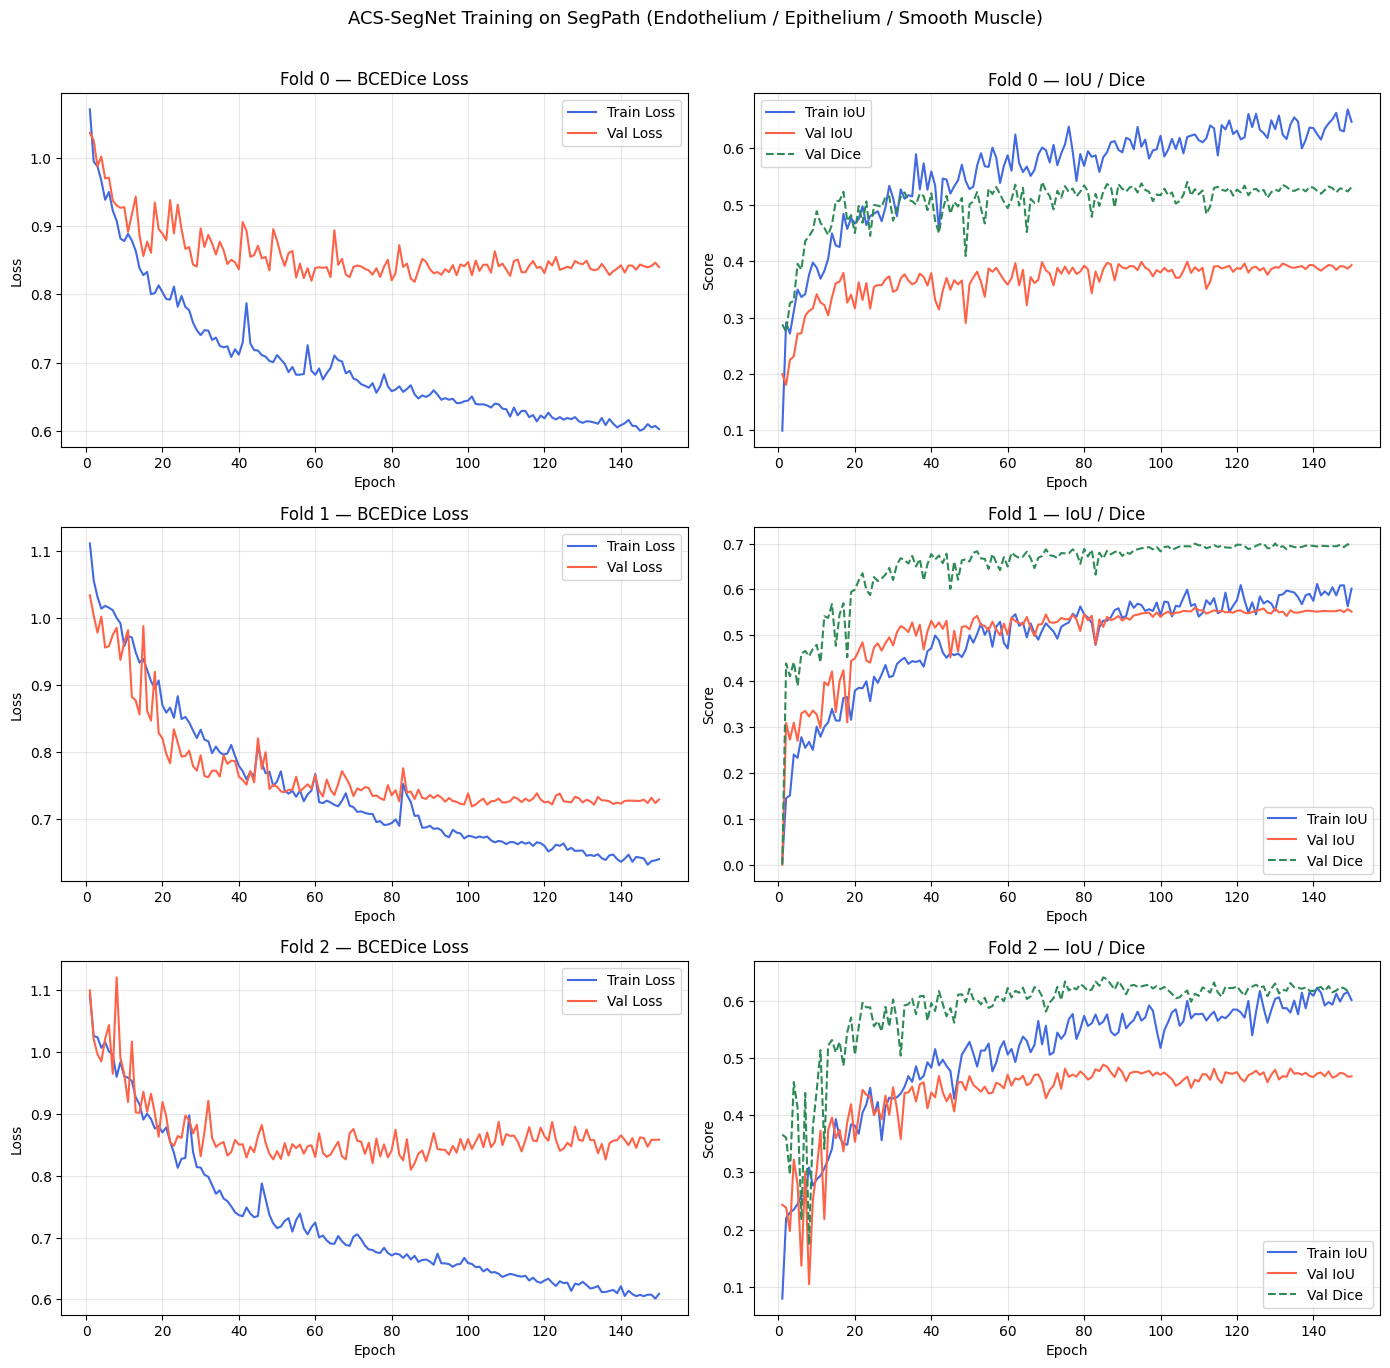

Saved → /content/drive/MyDrive/ACS_SegNet_SegPath/training_curves.png


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(CFG['n_folds'], 2, figsize=(14, 4.5 * CFG['n_folds']))

for fi in range(CFG['n_folds']):
    h   = fold_histories[fi]
    eps = range(1, len(h['train_loss']) + 1)

    ax_l = axes[fi][0]
    ax_l.plot(eps, h['train_loss'], label='Train Loss', color='royalblue')
    ax_l.plot(eps, h['val_loss'],   label='Val Loss',   color='tomato')
    ax_l.set_title(f'Fold {fi} — BCEDice Loss')
    ax_l.set_xlabel('Epoch'); ax_l.set_ylabel('Loss')
    ax_l.legend(); ax_l.grid(alpha=0.3)

    ax_m = axes[fi][1]
    ax_m.plot(eps, h['train_iou'],  label='Train IoU',  color='royalblue')
    ax_m.plot(eps, h['val_iou'],    label='Val IoU',    color='tomato')
    ax_m.plot(eps, h['val_dice'],   label='Val Dice',   color='seagreen', linestyle='--')
    ax_m.set_title(f'Fold {fi} — IoU / Dice')
    ax_m.set_xlabel('Epoch'); ax_m.set_ylabel('Score')
    ax_m.legend(); ax_m.grid(alpha=0.3)

plt.suptitle('ACS-SegNet Training on SegPath (Endothelium / Epithelium / Smooth Muscle)',
             fontsize=13, y=1.01)
plt.tight_layout()
p = os.path.join(CFG['drive_save'], 'training_curves.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print('Saved →', p)

## Cell 11 — Load Best Checkpoint & Final Validation

In [13]:
# Pick the fold with the highest best_iou automatically
EVAL_FOLD = max(fold_results, key=fold_results.get)
print(f'Best fold: {EVAL_FOLD}  (val IoU = {fold_results[EVAL_FOLD]:.4f})')

ckpt = os.path.join(CFG['checkpoint_dir'], f'ACSSegNet_fold{EVAL_FOLD}_best.pth')
eval_model = build_model()
eval_model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
eval_model.eval()
print(f'Loaded: {ckpt}')

_, eval_val_loader = get_dataloaders(EVAL_FOLD)
criterion = BCEDiceLoss().to(DEVICE)
val_m = validate(eval_model, eval_val_loader, criterion)

print(f'\n── Final Validation Metrics (Fold {EVAL_FOLD}) ──────────────')
metric_names = ['iou','dice','SE','PC','F1','SP','ACC']
full_names   = ['IoU','Dice','Sensitivity','Precision','F1','Specificity','Accuracy']
for k, name in zip(metric_names, full_names):
    print(f'  {name:<15}: {val_m[k].avg:.4f}')

Best fold: 1  (val IoU = 0.5599)


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerModel LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                                           | Status     |  | 
----------------------------------------------+------------+--+-
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | UNEXPECTED |  | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | UNEXPECTED |  | 
decode_head.batch_norm.bias                   | UNEXPECTED |  | 
decode_head.batch_norm.weight                 | UNEXPECTED |  | 
decode_head.batch_norm.num_batches_tracked    | UNEXPECTED |  | 
decode_head.batch_norm.running_var            | UNEXPECTED |  | 
decode_head.linear_fuse.weight                | UNEXPECTED |  | 
decode_head.classifier.weight                 | UNEXPECTED |  | 
decode_head.classifier.bias                   | UNEXPECTED |  | 
decode_head.batch_norm.running_mean           | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ACS-SegNet parameters: 50.4 M
Loaded: /content/checkpoints/ACSSegNet_fold1_best.pth
  [SegPath1_train.txt]  200 samples
  [SegPath1_val.txt]  100 samples

── Final Validation Metrics (Fold 1) ──────────────
  IoU            : 0.5599
  Dice           : 0.6998
  Sensitivity    : 0.7092
  Precision      : 0.7122
  F1             : 0.6998
  Specificity    : 0.9549
  Accuracy       : 0.9284


## Cell 11b — Paper-Protocol µIoU / µDice (Eq. 1–3, added by audit)
The repo's `iou_score`+`AverageMeter` averages per-batch IoU. The **paper** treats the entire validation set as one image: accumulate cumulative TP/FP/FN, compute micro-IoU/Dice **per class**, then average across classes. This cell reports that number, which is the one comparable to the paper's protocol.

In [14]:
# FIX(F4): true paper micro-metric (whole val set as one image; per-class then averaged)
@torch.no_grad()
def paper_micro_metrics(model, loader):
    model.eval()
    agg = defaultdict(lambda: {'TP': 0, 'FP': 0, 'FN': 0})
    for batch in loader:
        imgs   = batch['image'].to(DEVICE)
        labels = batch['label'].to(DEVICE)
        stems  = batch['stem']
        preds  = (torch.sigmoid(model(imgs)) > 0.5)
        gts    = (labels > 0.5)
        for b in range(imgs.size(0)):
            ct = stems[b].split('__')[0]
            p, g = preds[b].bool(), gts[b].bool()
            agg[ct]['TP'] += int((p & g).sum())
            agg[ct]['FP'] += int((p & ~g).sum())
            agg[ct]['FN'] += int((~p & g).sum())
    per_cls = {}
    for ct, d in agg.items():
        tp, fp, fn = d['TP'], d['FP'], d['FN']
        iou  = tp / (tp + fp + fn + 1e-9)
        dice = 2 * tp / (2 * tp + fp + fn + 1e-9)
        per_cls[ct] = {'uIoU': iou, 'uDice': dice}
    macro_iou  = float(np.mean([v['uIoU']  for v in per_cls.values()]))
    macro_dice = float(np.mean([v['uDice'] for v in per_cls.values()]))
    return per_cls, macro_iou, macro_dice


per_cls_micro, mIoU, mDice = paper_micro_metrics(eval_model, eval_val_loader)
print(f'── Paper-protocol micro metrics (Fold {EVAL_FOLD}) ──')
for ct, v in per_cls_micro.items():
    print(f'  {ct:<16}  uIoU={v["uIoU"]:.4f}  uDice={v["uDice"]:.4f}')
print(f'  {"MEAN(over classes)":<16}  uIoU={mIoU:.4f}  uDice={mDice:.4f}')
paper_micro_summary = {'per_class': per_cls_micro, 'mean_uIoU': mIoU, 'mean_uDice': mDice}


── Paper-protocol micro metrics (Fold 1) ──
  endothelium       uIoU=0.0368  uDice=0.0710
  smooth_muscle     uIoU=0.2651  uDice=0.4191
  epithelium        uIoU=0.7712  uDice=0.8708
  MEAN(over classes)  uIoU=0.3577  uDice=0.4536


## Cell 12 — Qualitative Results (2 samples per cell type)

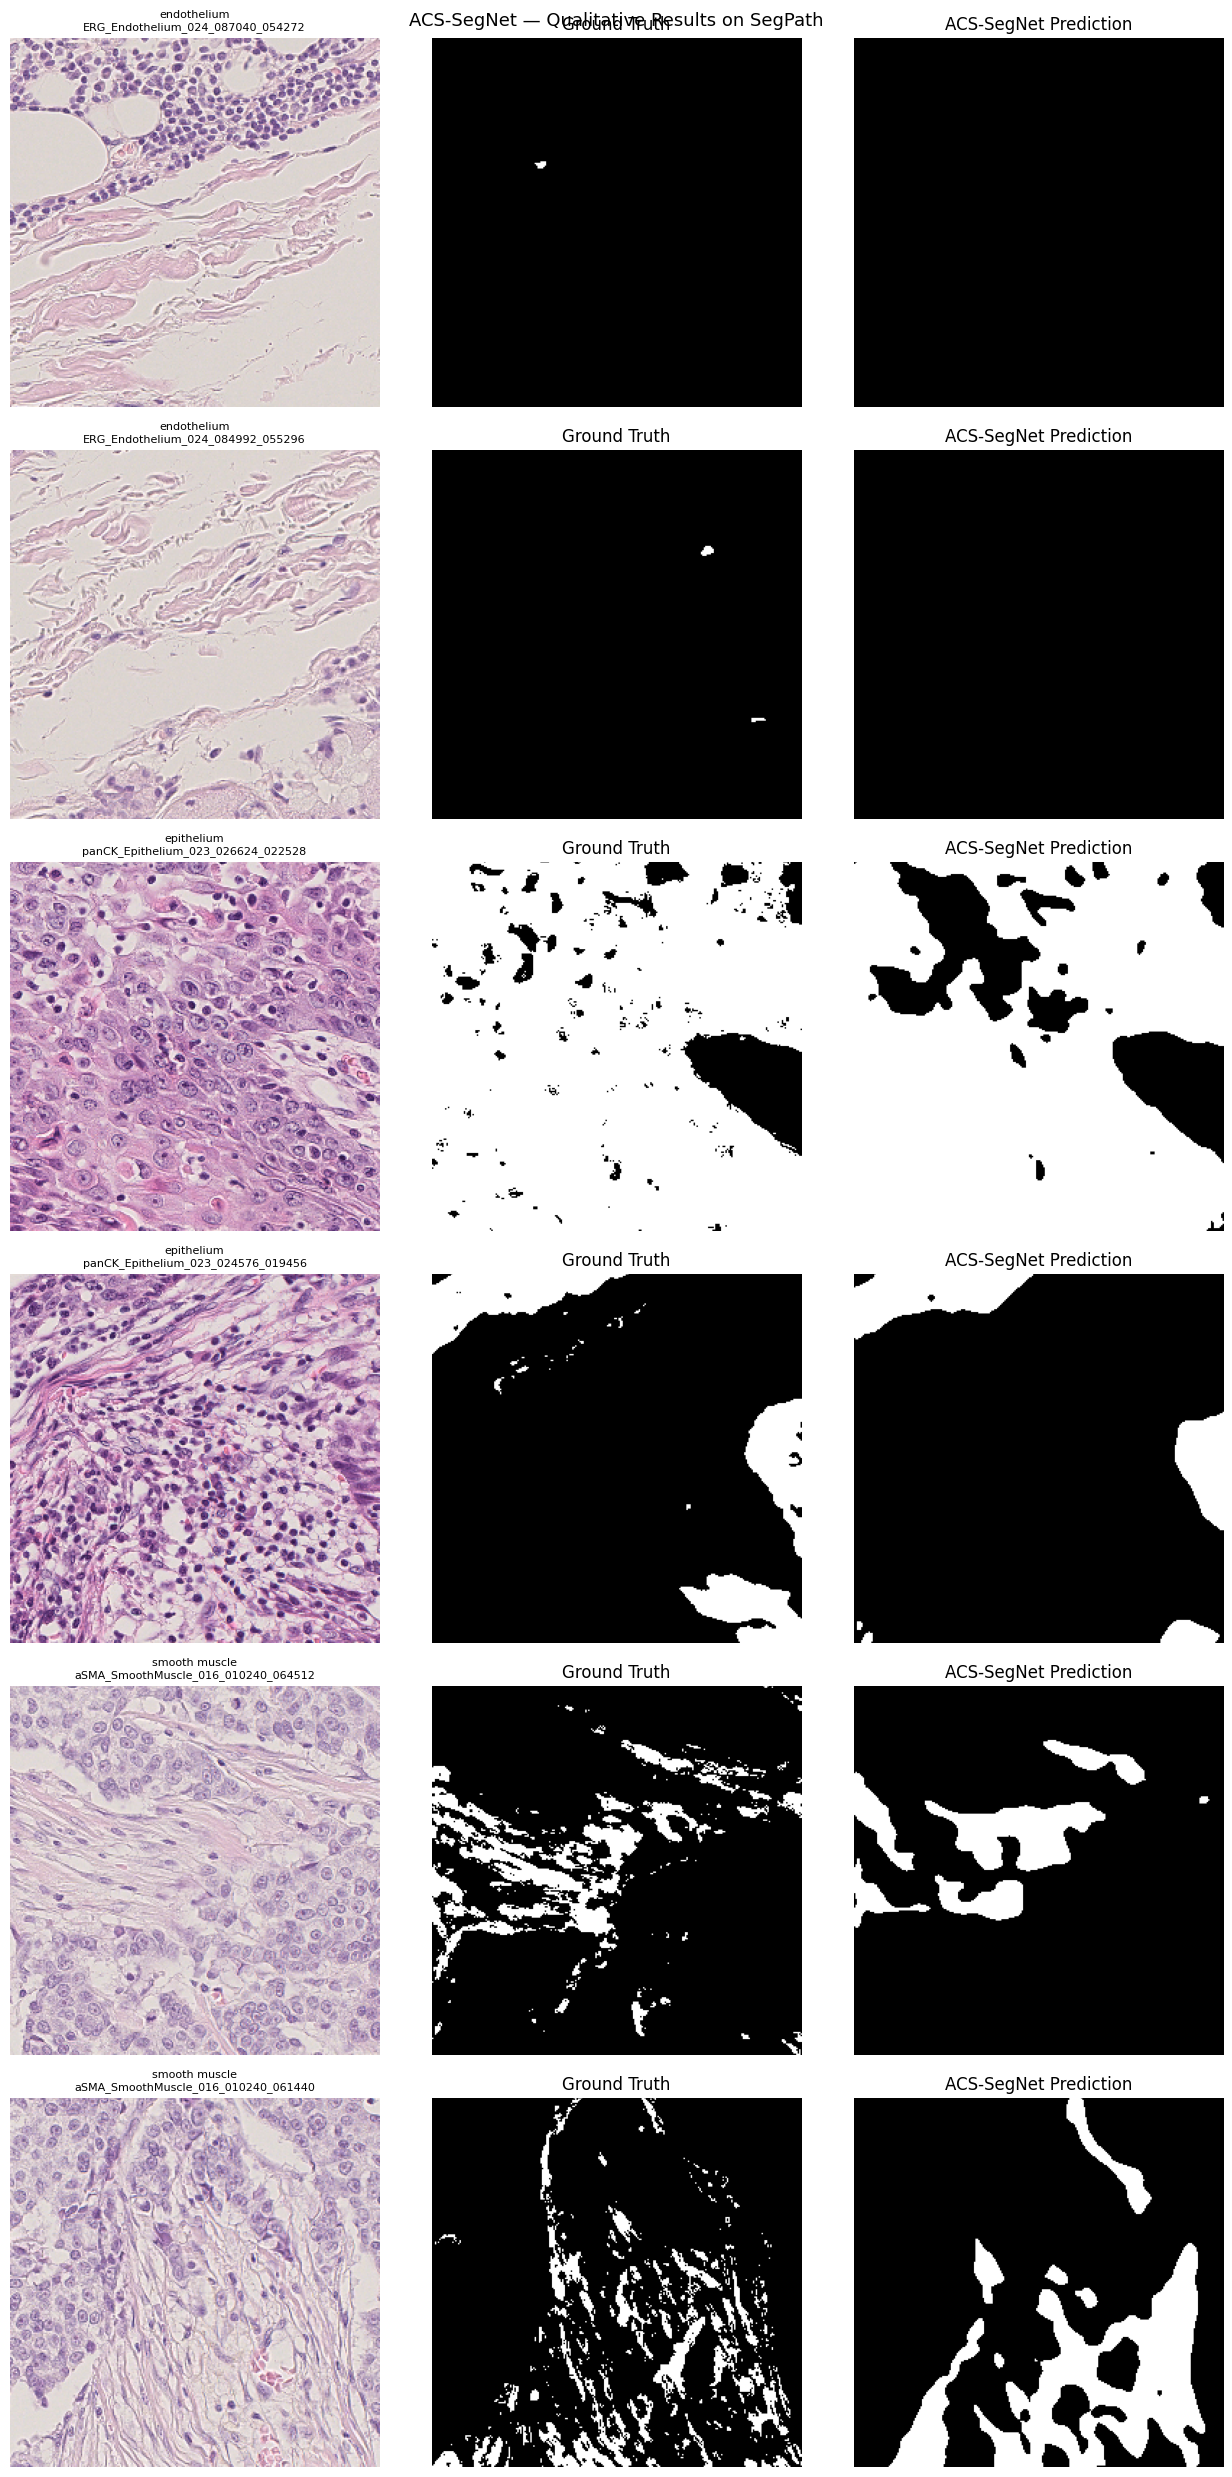

Saved → /content/drive/MyDrive/ACS_SegNet_SegPath/qualitative_results.png


In [15]:
N_PER_CLASS = 2   # how many samples to show per cell type
cell_types  = list(CFG['cell_types'].keys())
n_rows      = len(cell_types) * N_PER_CLASS

fig, axes = plt.subplots(n_rows, 3, figsize=(13, 4.2 * n_rows))

# Collect N_PER_CLASS samples per cell type from the validation set
collected = defaultdict(list)

eval_model.eval()
with torch.no_grad():
    for batch in eval_val_loader:
        imgs   = batch['image'].to(DEVICE)
        labels = batch['label']
        stems  = batch['stem']
        preds  = torch.sigmoid(eval_model(imgs)).cpu()

        for b in range(imgs.size(0)):
            ct = stems[b].split('__')[0]
            if len(collected[ct]) < N_PER_CLASS:
                collected[ct].append({
                    'img' : imgs[b].cpu().numpy().transpose(1, 2, 0),
                    'mask': labels[b, 0].numpy(),
                    'pred': (preds[b, 0].numpy() > 0.5).astype('uint8'),
                    'stem': stems[b],
                })

        if all(len(v) >= N_PER_CLASS for v in collected.values()):
            break

row = 0
for ct in cell_types:
    for entry in collected.get(ct, []):
        base_id = entry['stem'].split('__')[1] if '__' in entry['stem'] else entry['stem']
        short   = base_id[:35] + '...' if len(base_id) > 35 else base_id

        axes[row][0].imshow(entry['img'])
        axes[row][0].set_title(f"{ct.replace('_',' ')}\n{short}", fontsize=8)
        axes[row][0].axis('off')

        axes[row][1].imshow(entry['mask'], cmap='gray')
        axes[row][1].set_title('Ground Truth')
        axes[row][1].axis('off')

        axes[row][2].imshow(entry['pred'], cmap='gray')
        axes[row][2].set_title('ACS-SegNet Prediction')
        axes[row][2].axis('off')

        row += 1

plt.suptitle('ACS-SegNet — Qualitative Results on SegPath', fontsize=13)
plt.tight_layout()
p = os.path.join(CFG['drive_save'], 'qualitative_results.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print('Saved →', p)

## Cell 13 — Per-Class Breakdown (Endothelium / Epithelium / Smooth Muscle)

Cell Type                   N       IoU      Dice    Sensitivity   Precision        F1    Accuracy
--------------------------------------------------------------------------------------------------
endothelium                35    0.3798    0.3860         0.0179      0.2725    0.0149      0.3691
epithelium                 34    0.6837    0.7797         0.7929      0.7752    0.7797      0.9185
smooth_muscle              31    0.2420    0.3801         0.3911      0.4342    0.3801      0.8615


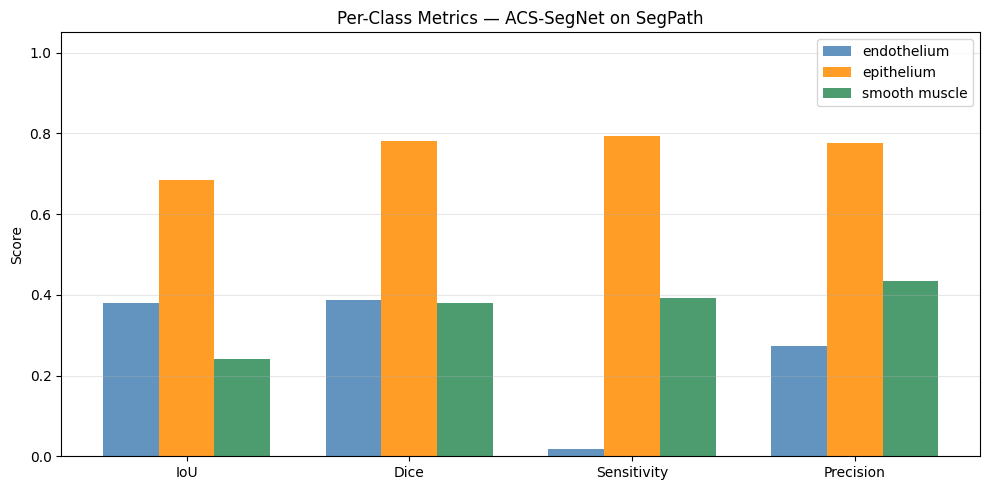

Saved → /content/drive/MyDrive/ACS_SegNet_SegPath/per_class_metrics.png


In [16]:
from collections import defaultdict

per_class = defaultdict(lambda: defaultdict(list))

eval_model.eval()
with torch.no_grad():
    for batch in eval_val_loader:
        imgs   = batch['image'].to(DEVICE)
        labels = batch['label'].to(DEVICE)
        stems  = batch['stem']
        preds  = eval_model(imgs)

        for b in range(imgs.size(0)):
            ct = stems[b].split('__')[0]
            iou, dice, SE, PC, F1, SP, ACC = iou_score(preds[b:b+1], labels[b:b+1])
            for k, v in zip(['iou','dice','SE','PC','F1','ACC'], [iou,dice,SE,PC,F1,ACC]):
                per_class[ct][k].append(v)

# ── Pretty table ──────────────────────────────────────────────────────────────
hdr = f'{"Cell Type":<22}  {"N":>5}  {"IoU":>8}  {"Dice":>8}  {"Sensitivity":>13}  {"Precision":>10}  {"F1":>8}  {"Accuracy":>10}'
print(hdr)
print('-' * len(hdr))
for ct in CFG['cell_types']:
    d = per_class.get(ct, {})
    if not d: continue
    n = len(d['iou'])
    print(
        f'{ct:<22}  {n:>5}  '
        f'{np.mean(d["iou"]):>8.4f}  '
        f'{np.mean(d["dice"]):>8.4f}  '
        f'{np.mean(d["SE"]):>13.4f}  '
        f'{np.mean(d["PC"]):>10.4f}  '
        f'{np.mean(d["F1"]):>8.4f}  '
        f'{np.mean(d["ACC"]):>10.4f}'
    )

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
metrics_to_plot = ['iou', 'dice', 'SE', 'PC']
x = np.arange(len(metrics_to_plot))
w = 0.25
colors = ['steelblue', 'darkorange', 'seagreen']

for i, ct in enumerate(CFG['cell_types']):
    d = per_class.get(ct, {})
    if not d: continue
    vals = [np.mean(d[m]) for m in metrics_to_plot]
    ax.bar(x + i * w, vals, w, label=ct.replace('_',' '), color=colors[i], alpha=0.85)

ax.set_xticks(x + w)
ax.set_xticklabels(['IoU', 'Dice', 'Sensitivity', 'Precision'])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Per-Class Metrics — ACS-SegNet on SegPath')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
p = os.path.join(CFG['drive_save'], 'per_class_metrics.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print('Saved →', p)

## Cell 14 — Save Full Results JSON to Drive

In [17]:
import json, datetime

results_log = {
    'timestamp'     : datetime.datetime.now().isoformat(),
    'model'         : 'ACS-SegNet (ResNet34 + SegFormer-B2 + CBAM)',
    'dataset'       : 'SegPath (endothelium, epithelium, smooth_muscle)',
    'config'        : {k: str(v) for k, v in CFG.items()},
    'fold_best_iou' : {str(k): round(float(v), 6) for k, v in fold_results.items()},
    'mean_iou'      : round(float(np.mean(ious)), 6),
    'std_iou'       : round(float(np.std(ious)),  6),
    'paper_micro'   : paper_micro_summary,   # FIX(F7): paper-protocol µ-metrics
    'per_class'     : {
        ct: {m: round(float(np.mean(vals)), 6) for m, vals in metrics.items()}
        for ct, metrics in per_class.items()
    },
}

log_path = os.path.join(CFG['drive_save'], 'results_summary.json')
with open(log_path, 'w') as f:
    json.dump(results_log, f, indent=2)

print('Results saved to:', log_path)
print()
print(json.dumps(results_log, indent=2))

Results saved to: /content/drive/MyDrive/ACS_SegNet_SegPath/results_summary.json

{
  "timestamp": "2026-07-08T21:22:43.714661",
  "model": "ACS-SegNet (ResNet34 + SegFormer-B2 + CBAM)",
  "dataset": "SegPath (endothelium, epithelium, smooth_muscle)",
  "config": {
    "data_root": "/content/SegPath_sorted",
    "data_dir": "/content/ACS_data",
    "cell_types": "{'endothelium': ('_HE', '_mask'), 'epithelium': ('_HE', '_mask'), 'smooth_muscle': ('_HE', '_mask')}",
    "img_size": "256",
    "num_classes": "1",
    "segformer_var": "nvidia/segformer-b2-finetuned-ade-512-512",
    "resnet_enc": "resnet34",
    "decoder_ch": "(256, 128, 64, 32, 16)",
    "simple_fusion": "1",
    "use_intensity_aug": "True",
    "epochs": "150",
    "batch_size": "4",
    "lr": "0.01",
    "momentum": "0.9",
    "weight_decay": "0.0001",
    "n_folds": "3",
    "seed": "42",
    "checkpoint_dir": "/content/checkpoints",
    "result_dir": "/content/results",
    "drive_save": "/content/drive/MyDrive/ACS_Se

---
## Optional — Single Image Inference
Run inference on any new SegPath image (provide the full path to the `_HE.png` file).

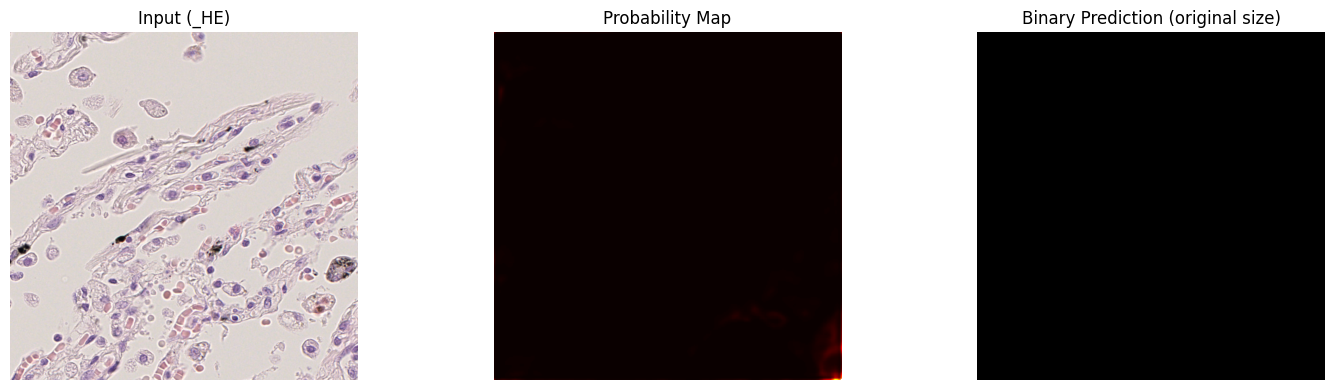

In [18]:
# ── EDIT: path to any _HE.png image ──────────────────────────────────────────
TEST_IMG = '/content/SegPath_sorted/endothelium/images/ERG_Endothelium_024_067584_052224_HE.png'
# ─────────────────────────────────────────────────────────────────────────────

from albumentations import Compose, Resize

orig = cv2.cvtColor(cv2.imread(TEST_IMG), cv2.COLOR_BGR2RGB)
H0, W0 = orig.shape[:2]

resized = Compose([Resize(CFG['img_size'], CFG['img_size'])])(image=orig)['image']
inp     = torch.tensor((resized / 255.0).transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)

eval_model.eval()
with torch.no_grad():
    prob = torch.sigmoid(eval_model(inp))[0, 0].cpu().numpy()

pred_bin  = (prob > 0.5).astype('uint8') * 255
pred_full = cv2.resize(pred_bin, (W0, H0), interpolation=cv2.INTER_NEAREST)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(orig);             axes[0].set_title('Input (_HE)');       axes[0].axis('off')
axes[1].imshow(prob, cmap='hot'); axes[1].set_title('Probability Map');   axes[1].axis('off')
axes[2].imshow(pred_full, cmap='gray'); axes[2].set_title('Binary Prediction (original size)'); axes[2].axis('off')
plt.tight_layout()
plt.show()